In [26]:
import pandas as pd
from sklearn.impute import SimpleImputer

df = pd.read_csv('data/mimic-iv-bigquery-results-14052026.csv')

In [2]:
'''
cols_2_drop = ['organisms_cultured', 
               'specimen_types', 
               'subject_id',
               'hadm_id',
               'race', 
               'insurance', 
               'admission_type']

df = df.drop(columns=cols_2_drop)
'''

"\ncols_2_drop = ['organisms_cultured', \n               'specimen_types', \n               'subject_id',\n               'hadm_id',\n               'race', \n               'insurance', \n               'admission_type']\n\ndf = df.drop(columns=cols_2_drop)\n"

In [27]:
missing_cols = df.columns[df.isna().any()].tolist()

In [28]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct
})

print(summary)


                  missing_count  missing_pct
fibrinogen_max           198509        100.0
fibrinogen_first         198509        100.0
ast_max                  198509        100.0
ast_first                198509        100.0
bun_max                  198509        100.0
...                         ...          ...
hemoglobin_max             4006          2.0
hemoglobin_first           4006          2.0
hematocrit_max             3103          1.6
hematocrit_first           3103          1.6
insurance                  2066          1.0

[68 rows x 2 columns]


In [32]:
cols_to_drop = df.columns[df.isna().mean() == 1].tolist()
df = df.drop(columns=cols_to_drop)

In [33]:
df

,subject_id,hadm_id,age,gender,race,insurance,admission_type,los_hours,hospital_expire_flag,wbc_first,...,chloride_max,calcium_first,calcium_max,magnesium_first,magnesium_max,phosphate_first,phosphate_max,organisms_cultured,specimen_types,had_resistance
0,10000032,22595853,52,F,WHITE,Medicaid,URGENT,19,0,NaN,...,105.0,7.8,7.8,1.7,1.7,3.6,3.6,NaN,"PERITONEAL FLUID, SWAB, URINE",0
1,10000032,22841357,52,F,WHITE,Medicaid,EW EMER.,24,0,13.0,...,92.0,7.8,7.8,1.9,1.9,3.3,3.3,NaN,"URINE, SWAB",0
2,10000032,25742920,52,F,WHITE,Medicaid,EW EMER.,42,0,NaN,...,95.0,8.6,8.8,2.4,2.4,3.9,3.9,NaN,SWAB,0
3,10000032,29079034,52,F,WHITE,Medicaid,EW EMER.,53,0,NaN,...,102.0,9.3,9.3,2.3,2.3,2.4,2.4,NaN,"SWAB, MRSA SCREEN",0
4,10000084,23052089,72,M,WHITE,Medicare,EW EMER.,109,0,NaN,...,104.0,9.9,9.9,2.0,2.0,3.7,3.7,NaN,BLOOD CULTURE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198504,19999828,25744818,46,F,WHITE,Medicaid,EW EMER.,241,0,NaN,...,109.0,9.0,9.3,2.3,2.9,1.1,5.0,"MIXED BACTERIAL FLORA, STREPTOCOCCUS ANGINOSUS...","SWAB, BLOOD CULTURE",0
198505,19999828,29734428,46,F,WHITE,Medicaid,EW EMER.,410,0,13.0,...,117.0,8.6,10.0,1.8,2.9,3.1,5.1,ESCHERICHIA COLI,"URINE, CATHETER TIP-IV, BLOOD CULTURE",1
198506,19999840,21033226,58,M,WHITE,Private,EW EMER.,168,1,NaN,...,117.0,9.3,9.3,2.1,2.2,4.0,4.9,ESCHERICHIA COLI,"SPUTUM, MRSA SCREEN, STOOL, BLOOD CULTURE",0
198507,19999840,26071774,58,M,WHITE,Private,EW EMER.,84,0,5.0,...,106.0,8.8,9.0,1.7,1.9,2.0,2.5,NaN,URINE,0


In [34]:
df.columns

Index(['subject_id', 'hadm_id', 'age', 'gender', 'race', 'insurance',
       'admission_type', 'los_hours', 'hospital_expire_flag', 'wbc_first',
       'wbc_max', 'bands_first', 'bands_max', 'neutrophils_first',
       'neutrophils_max', 'lymphocytes_first', 'lymphocytes_max',
       'monocytes_first', 'monocytes_max', 'crp_first', 'crp_max',
       'ferritin_first', 'ferritin_max', 'lactate_first', 'lactate_max',
       'creatinine_first', 'creatinine_max', 'bilirubin_total_first',
       'bilirubin_total_max', 'alt_first', 'alt_max', 'albumin_first',
       'albumin_max', 'glucose_first', 'glucose_max', 'inr_first', 'inr_max',
       'ptt_first', 'ptt_max', 'platelets_first', 'platelets_max',
       'd_dimer_first', 'd_dimer_max', 'ph_first', 'ph_max', 'po2_first',
       'po2_max', 'pco2_first', 'pco2_max', 'bicarbonate_first',
       'bicarbonate_max', 'hemoglobin_first', 'hemoglobin_max',
       'hematocrit_first', 'hematocrit_max', 'sodium_first', 'sodium_max',
       'potassium_

In [35]:
DROP_COLS  = ['subject_id', 'hadm_id', 'organisms_cultured', 'specimen_types', 'gender', 'race', 'insurance','admission_type']
CAT_COLS   = []
LAB_COLS = [c for c in df.columns
            if c.endswith('_first') or c.endswith('_max')]
TARGET_COL = 'had_resistance'

In [36]:
for col in LAB_COLS:
    df[f'{col}_missing'] = df[col].isna().astype(int)

In [37]:
df.shape

(198509, 128)

In [38]:
df = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)

In [39]:
df = df.drop(columns=DROP_COLS)

In [53]:
df[TARGET_COL]

0         0
1         0
2         0
3         0
4         0
         ..
198504    0
198505    1
198506    0
198507    0
198508    0
Name: had_resistance, Length: 198509, dtype: int64

In [54]:
df_balanced = pd.concat([
    df[df[TARGET_COL] == 0].sample(10000, random_state=42),
    df[df[TARGET_COL] == 1].sample(10000, random_state=42)
]).reset_index(drop=True)

In [56]:
df_balanced[TARGET_COL]

0        0
1        0
2        0
3        0
4        0
        ..
19995    1
19996    1
19997    1
19998    1
19999    1
Name: had_resistance, Length: 20000, dtype: int64

In [57]:
X = df_balanced.drop(columns=[TARGET_COL])
y = df_balanced[TARGET_COL]

In [58]:
X

,age,los_hours,hospital_expire_flag,wbc_first,wbc_max,bands_first,bands_max,neutrophils_first,neutrophils_max,lymphocytes_first,...,potassium_first_missing,potassium_max_missing,chloride_first_missing,chloride_max_missing,calcium_first_missing,calcium_max_missing,magnesium_first_missing,magnesium_max_missing,phosphate_first_missing,phosphate_max_missing
0,72,138,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,61,79,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,0,0,1,1
2,35,186,0,NaN,NaN,0.0,0.0,79.0,79.0,17.0,...,0,0,0,0,0,0,0,0,0,0
3,50,387,0,1.0,78.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,91,55,1,3.0,3.0,NaN,NaN,92.2,92.2,4.4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,40,1574,0,1.0,1.0,0.0,10.0,49.0,96.0,22.0,...,0,0,0,0,0,0,0,0,0,0
19996,53,408,0,1.0,1.0,NaN,NaN,88.9,88.9,1.8,...,0,0,0,0,0,0,0,0,0,0
19997,49,77,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
19998,56,154,0,270.0,270.0,33.0,33.0,22.0,22.0,25.0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
# See what's still non-numeric
print(X.select_dtypes(exclude='number').dtypes)

Series([], dtype: object)


In [60]:
median_imputer = SimpleImputer(strategy='median')
X_median = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=median_imputer.get_feature_names_out()
)

In [78]:
X_median.to_csv('data/features_imputed_median.csv')
y.to_csv('data/target_imputed_median.csv')

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import shap
import lime

import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as notebook_tqdm


import matplotlib.pyplot as plt

# Set globally for all plots
plt.rcParams.update({
    "figure.figsize": (10, 6),   # width, height in inches
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
import warnings
warnings.filterwarnings('ignore')

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X_median, y, test_size=0.3, train_size=0.7, random_state=42)

In [64]:
models = {
    'decision_tree': DecisionTreeClassifier(),
    'random_forest': RandomForestClassifier(),
    'gradient_boosting':GradientBoostingClassifier()
}

model_perfomance = {}
shap_values = {}

for model_name in models:
    model = models[model_name]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    model_perfomance[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                    'f1_score': f1_score(y_test, y_pred)}


print(model_perfomance)

{'decision_tree': {'accuracy': 0.5898333333333333, 'f1_score': 0.585899377418812}, 'random_forest': {'accuracy': 0.685, 'f1_score': 0.6846846846846847}, 'gradient_boosting': {'accuracy': 0.6895, 'f1_score': 0.6872586872586872}}


In [70]:
model = DecisionTreeClassifier(max_depth=4, random_state=42, max_leaf_nodes=32)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_test)

In [69]:
?DecisionTreeClassifier

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None

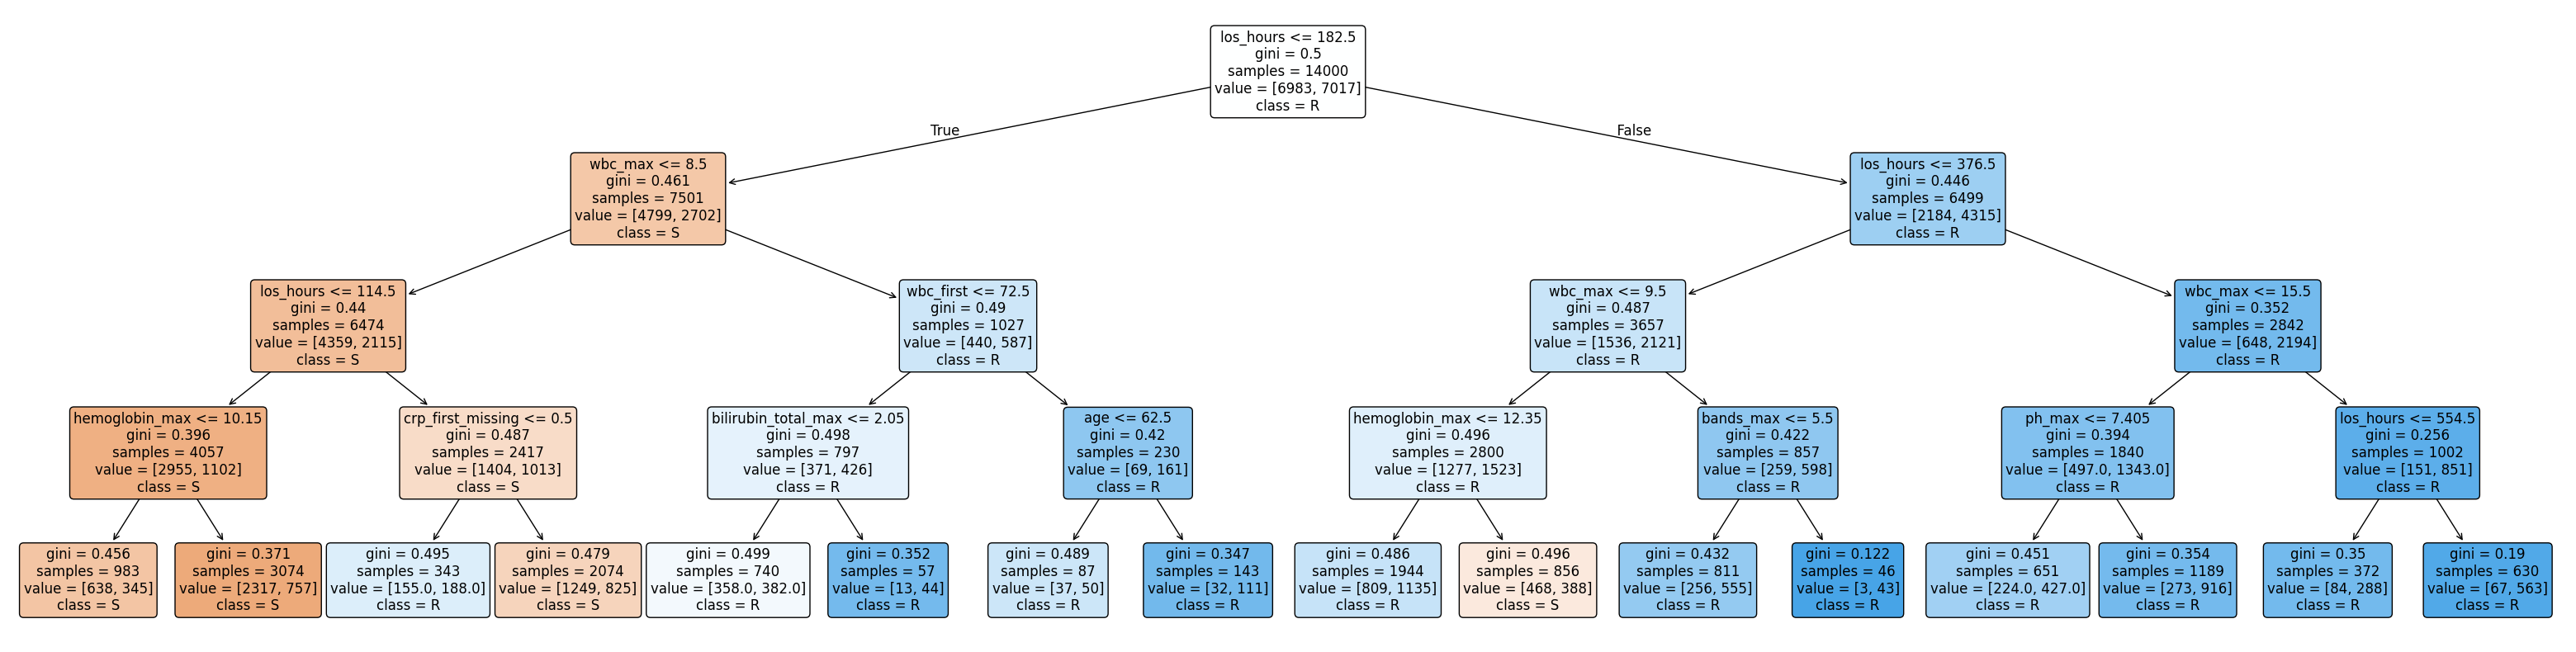

In [73]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(40, 10))
plot_tree(
    model,                            # your fitted DecisionTreeClassifier
    feature_names=X.columns.tolist(),
    class_names=['S', 'R'],
    filled=True,                    # colour nodes by class
    rounded=True,
    fontsize=12,
    ax=ax
)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
#explainer = shap.TreeExplainer(model)

#shap_values = explainer(X_test)

In [65]:
df_balanced

,age,los_hours,hospital_expire_flag,wbc_first,wbc_max,bands_first,bands_max,neutrophils_first,neutrophils_max,lymphocytes_first,...,potassium_first_missing,potassium_max_missing,chloride_first_missing,chloride_max_missing,calcium_first_missing,calcium_max_missing,magnesium_first_missing,magnesium_max_missing,phosphate_first_missing,phosphate_max_missing
0,72,138,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,61,79,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,0,0,1,1
2,35,186,0,NaN,NaN,0.0,0.0,79.0,79.0,17.0,...,0,0,0,0,0,0,0,0,0,0
3,50,387,0,1.0,78.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,91,55,1,3.0,3.0,NaN,NaN,92.2,92.2,4.4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,40,1574,0,1.0,1.0,0.0,10.0,49.0,96.0,22.0,...,0,0,0,0,0,0,0,0,0,0
19996,53,408,0,1.0,1.0,NaN,NaN,88.9,88.9,1.8,...,0,0,0,0,0,0,0,0,0,0
19997,49,77,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
19998,56,154,0,270.0,270.0,33.0,33.0,22.0,22.0,25.0,...,0,0,0,0,0,0,0,0,0,0
